In [ ]:
from datasets import load_from_disk
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
from PIL import Image
import requests
from io import BytesIO
import random

ds_train = load_from_disk("/home/elena/emcomm/datasets/winoground_features_resnet_152")

/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
def create_pairwise_tuples(ds, n_distractors=3, epoch=0, shuffle=True, seed=42):
    from sklearn.metrics.pairwise import cosine_similarity

    rng = np.random.default_rng(seed + epoch)

    image_0_list = ds["image_0"]
    image_1_list = ds["image_1"]

    # Stack all features for global sampling
    features_0 = np.array(ds["features_0"])
    features_1 = np.array(ds["features_1"])

    all_features = np.vstack([features_0, features_1])
    num_total = all_features.shape[0]

    tuples, labels = [], []
    
    count = 0
    total_sim = 0.0
    total_paired_sim = 0.0
    plot_dir = f"/home/elena/emcomm/emcomm_captions/winoground_epochs/data_{n_distractors}_distractors_{epoch}_epoch"
    if plot_dir:
        os.makedirs(plot_dir, exist_ok=True)


    def build_tuple(target_vec, paired_vec, target_img_idx, paired_img_idx, exclude_indices, idx_global):
        # candidates excluding target & its pair
        nonlocal total_sim, total_paired_sim, count

        available_indices = np.setdiff1d(np.arange(num_total), exclude_indices)

        n_candidates = min(n_distractors + epoch, len(available_indices))

        sampled = rng.choice(available_indices, size=n_candidates, replace=False)
        candidate_vectors = all_features[sampled]

        # similarity-based selection
        sims = cosine_similarity(target_vec[None, :], candidate_vectors).flatten()
        closest_idx = np.argsort(-sims)[:(n_distractors - 1)]

        distractors = candidate_vectors[closest_idx]
        distractors_idx = sampled[closest_idx]

        # ALWAYS include paired vector
        distractors = np.vstack([paired_vec[None, :], distractors])
        distractors_idx = np.concatenate([[paired_img_idx], distractors_idx])

        tuple_vectors = np.vstack([target_vec[None, :], distractors])
        tuple_idx = np.concatenate([[target_img_idx], distractors_idx])

        target_norm = target_vec / np.linalg.norm(target_vec)
        distractors_norm = distractors / np.linalg.norm(distractors, axis=1, keepdims=True)

        sims = distractors_norm @ target_norm  # shape: (n_distractors,)
        total_sim += sims.mean()
        paired_sim = sims[0]  # because you stacked it first
        total_paired_sim += paired_sim

        count += 1

        if shuffle:
            perm = rng.permutation(n_distractors + 1)
            tuple_vectors = tuple_vectors[perm]
            label = int(np.where(perm == 0)[0][0])
        else:
            label = 0
        # n_plot = 10
        # if plot_dir and count < n_plot:
        if plot_dir and random.random() < 0.02:
            fig, axes = plt.subplots(1, len(tuple_vectors), figsize=(3*len(tuple_vectors), 3))
            # print(len(tuple_vectors))
            if len(tuple_vectors) == 1:
                axes = [axes]
            for j, idx in enumerate(tuple_idx):
                # print(j)
                if idx < len(image_0_list):
                    img = image_0_list[idx]   # already a PIL Image
                else:
                    img = image_1_list[idx - len(image_0_list)]
                axes[j].imshow(img)
                axes[j].axis('off')
                # print(f"Label: {label}")
                if j == 1:
                    axes[j].set_title("Anchor", color='red')
                elif j == 0:
                    axes[j].set_title("Paired", color='blue')
                else:
                    axes[j].set_title(f"Distractor {j}")
            plt.tight_layout()
            plt.show()
            # plt.savefig(os.path.join(plot_dir, f"tuple_{count}.png"))
            plt.close()

        return tuple_vectors, label

    for i in tqdm(range(len(ds))):
        f0 = features_0[i]
        f1 = features_1[i]

        # indices in stacked array
        idx_0 = i
        idx_1 = i + len(ds)

        # case 1: target = f0
        t, l = build_tuple(
            target_vec=f0,
            paired_vec=f1,
            target_img_idx=i,
            paired_img_idx=idx_1,
            exclude_indices=[idx_0, idx_1],
            idx_global=2*i
        )
        tuples.append(t)
        labels.append(l)

        # case 2: target = f1
        t, l = build_tuple(
            target_vec=f1,
            paired_vec=f0,
            target_img_idx=idx_1,
            paired_img_idx=i,
            exclude_indices=[idx_0, idx_1],
            idx_global=2*i+1
        )
        tuples.append(t)
        labels.append(l)
    print(f"Average anchor–distractor similarity: {total_sim / count:.4f}")
    print(f"Avg paired sim:     {total_paired_sim / count:.4f}")
    return np.array(tuples), np.array(labels)

doing train data now: 


  0%|          | 0/100 [00:00<?, ?it/s]

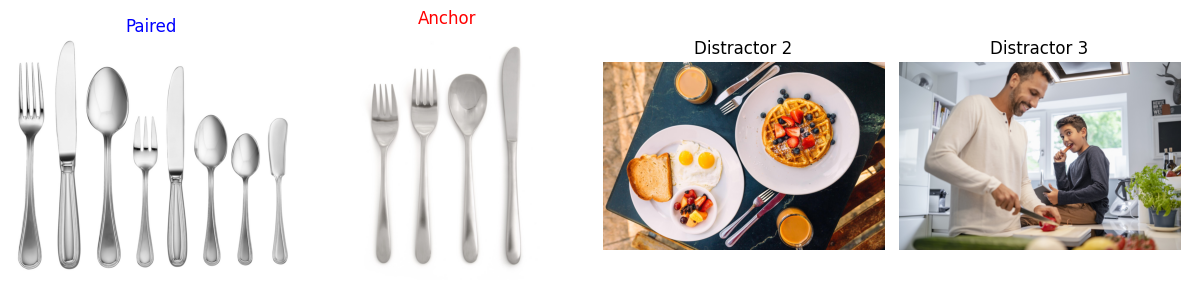

 17%|█▋        | 17/100 [00:00<00:03, 22.17it/s]

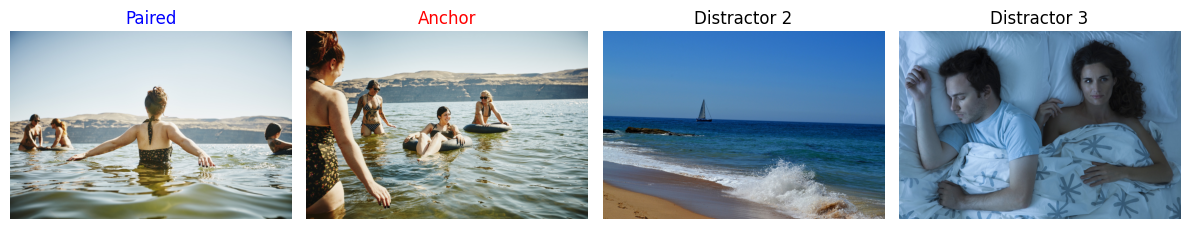

 24%|██▍       | 24/100 [00:01<00:05, 13.96it/s]

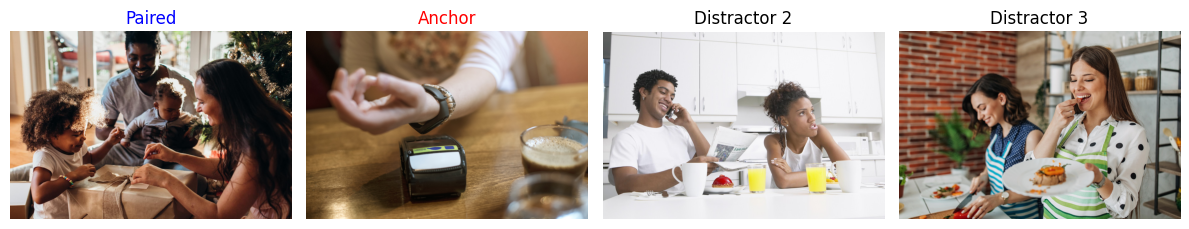

 74%|███████▍  | 74/100 [00:02<00:00, 35.76it/s]

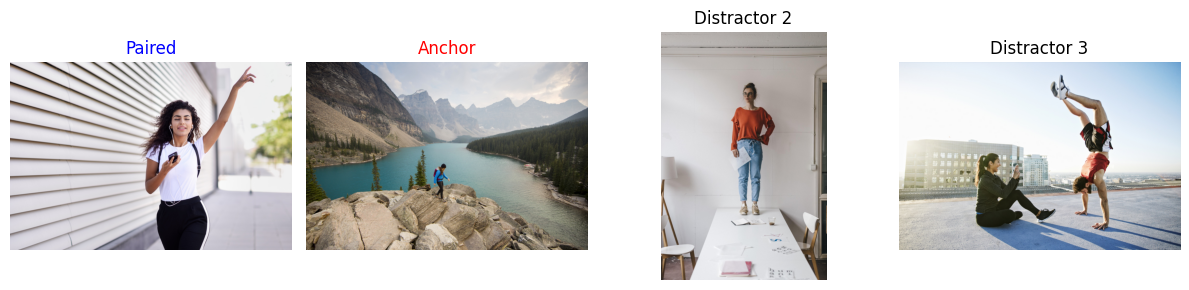

 78%|███████▊  | 78/100 [00:03<00:00, 23.49it/s]

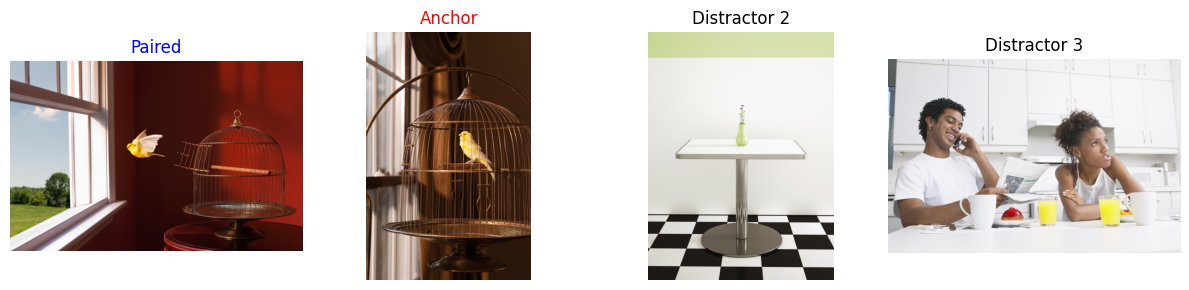

100%|██████████| 100/100 [00:03<00:00, 25.07it/s]

Average anchor–distractor similarity: 0.5817
Avg paired sim:     0.5536


In [6]:
n_distractors = 3
epoch = 0  # Set your curriculum learning epoch here
num_epochs = 101
print('doing train data now: ')
for epoch in range(100, num_epochs):
    # test_tuples, test_labels = create_exhaustive_tuples(np.array(ds_test["features"]), n_distractors=n_distractors, epoch=epoch, shuffle=True, seed=42)
    # valid_tuples, valid_labels = create_exhaustive_tuples(np.array(ds_val["features"]), n_distractors=n_distractors, epoch=epoch, shuffle=True, seed=42)
    # train_tuples, train_labels = create_exhaustive_tuples(np.array(ds_train["features"]), n_distractors=n_distractors, epoch=epoch, shuffle=True, seed=42)
    train_tuples, train_labels = create_pairwise_tuples(
        ds_train.select(range(100)),
        n_distractors=3,
        epoch=epoch,
        shuffle=False,
        seed=42
    )
    valid_tuples, valid_labels = train_tuples, train_labels
    test_tuples, test_labels = train_tuples, train_labels
#     np.savez_compressed(
#     f"/home/elena/emcomm/emcomm_captions/winoground_epochs/data_{n_distractors}_distractors_{epoch}_epoch.npz",
#     train=train_tuples,
#     train_labels=train_labels,
#     valid=valid_tuples,
#     valid_labels=valid_labels,
#     test=test_tuples,
#     test_labels=test_labels,
#     n_distractors=3
# )



